<a href="https://colab.research.google.com/github/Architag1503/Colab/blob/main/QLearning.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# **Interview Code**

In [1]:
import numpy as np

# number of states and actions
n_states = 5
n_actions = 2

# Q-table
Q = np.zeros((n_states, n_actions))

# parameters
alpha = 0.1
gamma = 0.9
epsilon = 0.1

# choose action using ε-greedy
def choose_action(state):
    if np.random.rand() < epsilon:
        return np.random.randint(n_actions)
    return np.argmax(Q[state])

# simple environment
def step(state, action):
    next_state = min(state + 1, n_states - 1)
    reward = 1 if next_state == n_states - 1 else 0
    return next_state, reward

# training
for episode in range(100):
    state = 0

    while state != n_states - 1:
        action = choose_action(state)
        next_state, reward = step(state, action)

        # Q-learning update (MOST IMPORTANT LINE)
        Q[state, action] += alpha * (
            reward + gamma * np.max(Q[next_state]) - Q[state, action]
        )

        state = next_state

print("Q-table:\n", Q)

Q-table:
 [[0.72199673 0.16552418]
 [0.8079998  0.13911204]
 [0.89958349 0.240217  ]
 [0.99995502 0.40951   ]
 [0.         0.        ]]


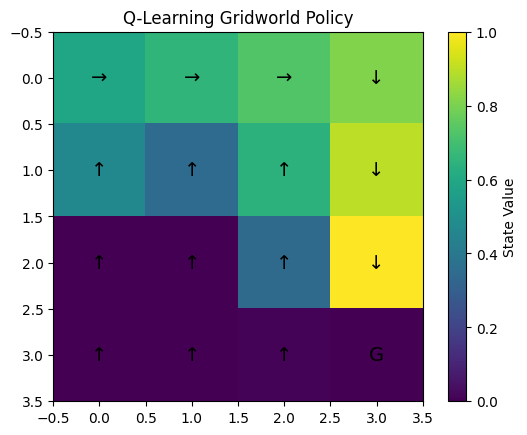

In [5]:
import numpy as np
import matplotlib.pyplot as plt

# Grid size
n = 4

# Actions: up, down, left, right
actions = [(-1,0), (1,0), (0,-1), (0,1)]
action_symbols = ['↑','↓','←','→']

# Q-table: (state_x, state_y, action)
Q = np.zeros((n, n, 4))

# Parameters
alpha = 0.1
gamma = 0.9
epsilon = 0.1

start = (0, 0)
goal = (n-1, n-1)

def choose_action(state):
    """ε-greedy action selection"""
    if np.random.rand() < epsilon:
        return np.random.randint(4)
    return np.argmax(Q[state[0], state[1]])

def step(state, action):
    """Take action and return next state + reward"""
    if state == goal:
        return state, 0

    move = actions[action]
    next_state = (state[0] + move[0], state[1] + move[1])

    # keep inside grid
    next_state = (
        max(0, min(n-1, next_state[0])),
        max(0, min(n-1, next_state[1]))
    )

    reward = 1 if next_state == goal else 0
    return next_state, reward


# =========================
# Training (Q-Learning)
# =========================
episodes = 500

for ep in range(episodes):
    state = start

    while state != goal:
        action = choose_action(state)
        next_state, reward = step(state, action)

        # Q-Learning update (IMPORTANT)
        Q[state[0], state[1], action] += alpha * (
            reward + gamma * np.max(Q[next_state[0], next_state[1]])
            - Q[state[0], state[1], action]
        )

        state = next_state


# =========================
# Extract Policy (Best Action)
# =========================
policy = np.empty((n, n), dtype=str)

for i in range(n):
    for j in range(n):
        if (i, j) == goal:
            policy[i, j] = 'G'
        else:
            best_action = np.argmax(Q[i, j])
            policy[i, j] = action_symbols[best_action]


# =========================
# Visualization
# =========================
plt.figure()
plt.imshow(np.max(Q, axis=2))  # state values heatmap

# draw arrows
for i in range(n):
    for j in range(n):
        plt.text(j, i, policy[i, j], ha='center', va='center', fontsize=14)

plt.title("Q-Learning Gridworld Policy")
plt.colorbar(label="State Value")
plt.show()